In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [10]:
df = pd.read_csv("../data/tesla_deliveries_dataset_2015_2025.csv")

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## Dataset Overview

In [11]:
print("Shape of dataset:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Info:")
df.info()

Shape of dataset: (2640, 12)

Columns:
Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   floa

## Missing Values

In [12]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

No missing values were found in the dataset.

## Numerical Summary

In [13]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


## Correlation Analysis

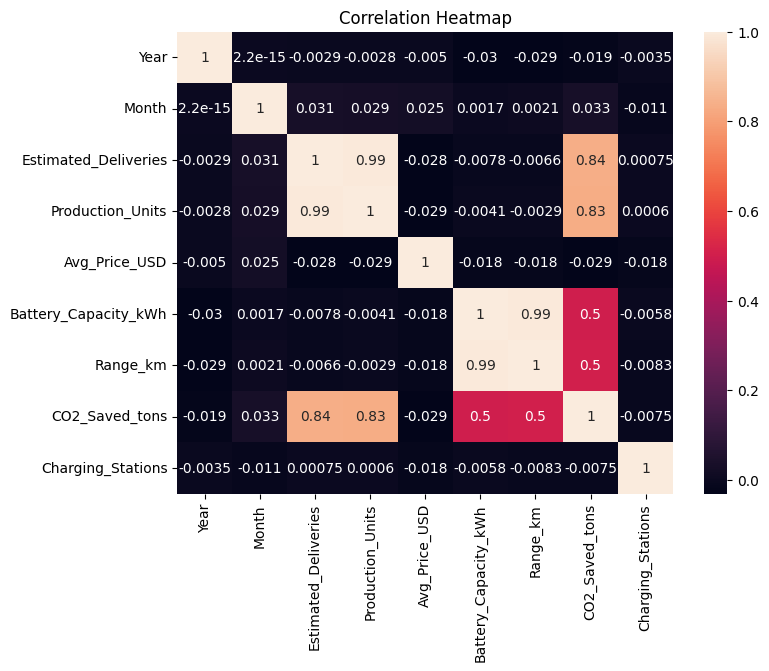

In [14]:
num_cols = df.select_dtypes(include="number")

plt.figure(figsize=(8,6))
sns.heatmap(num_cols.corr(), annot=True)

plt.title("Correlation Heatmap")
plt.show()

## Deliveries by Region

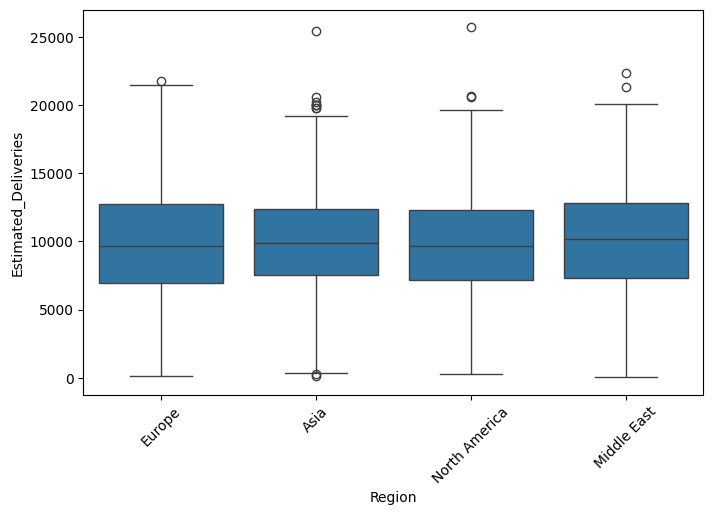

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Region",
    y="Estimated_Deliveries",
    data=df
)

plt.xticks(rotation=45)
plt.show()

## Feature Engineering

In [16]:
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()

df_model["Region"] = le_region.fit_transform(df_model["Region"])
df_model["Model"] = le_model.fit_transform(df_model["Model"])
df_model["Source_Type"] = le_source.fit_transform(df_model["Source_Type"])

df_model.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722


## Preparing Data for Regression

In [17]:
X = df_model.drop("Estimated_Deliveries", axis=1)
y = df_model["Estimated_Deliveries"]

print(X.shape)
print(y.shape)

(2640, 11)
(2640,)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(2112, 11)
(528, 11)


## Linear Regression

In [19]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [20]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, lr_pred)
rmse = mean_squared_error(y_test, lr_pred) ** 0.5
r2 = r2_score(y_test, lr_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 310.1300215468218
RMSE: 383.57656987039127
R2  : 0.9901296027802067


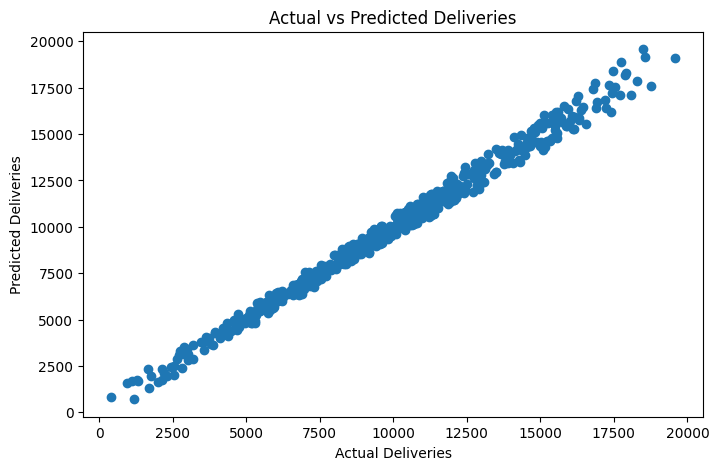

In [21]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, lr_pred)

plt.xlabel("Actual Deliveries")
plt.ylabel("Predicted Deliveries")
plt.title("Actual vs Predicted Deliveries")

plt.show()

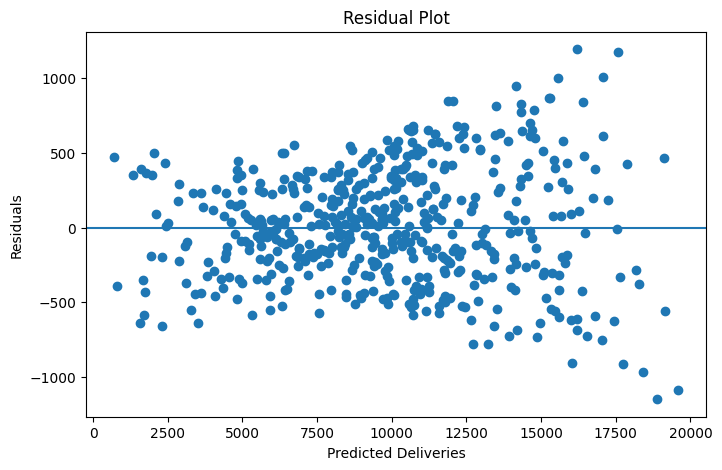

In [22]:
residuals = y_test - lr_pred

plt.figure(figsize=(8,5))

plt.scatter(lr_pred, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Deliveries")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [24]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})

coefficients.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
3,Model,4.804767
8,CO2_Saved_tons,2.155679
6,Battery_Capacity_kWh,1.881709
1,Month,1.445077
0,Year,0.967453
4,Production_Units,0.768549
10,Charging_Stations,0.002224
5,Avg_Price_USD,0.000453
2,Region,-3.399724
7,Range_km,-3.629959


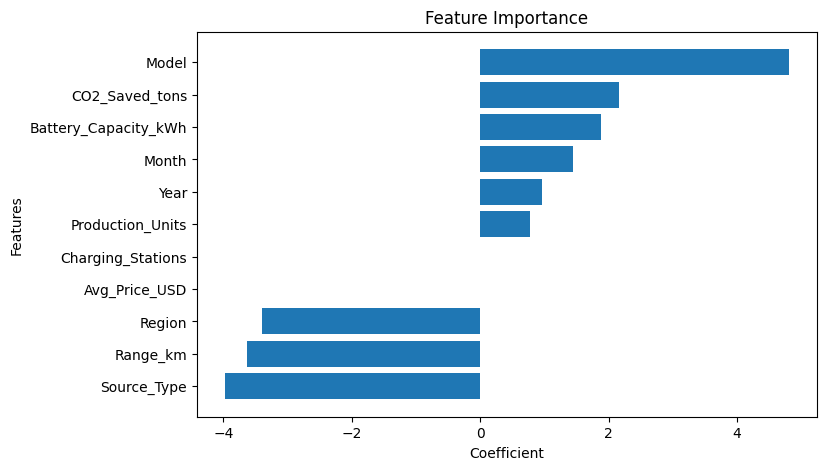

In [25]:
coef_df = coefficients.sort_values(by="Coefficient")

plt.figure(figsize=(8,5))

plt.barh(coef_df["Feature"], coef_df["Coefficient"])

plt.title("Feature Importance")
plt.xlabel("Coefficient")
plt.ylabel("Features")

plt.show()

# Hyperparameter Tuning using Random Forest Regressor

In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest R2 Score:", rf_r2)

Random Forest R2 Score: 0.9885401109297571


# Time Series Forecasting

In [27]:
ts_data = df.groupby(["Year", "Month"])["Estimated_Deliveries"].sum().reset_index()

ts_data["Date"] = pd.to_datetime(
    ts_data["Year"].astype(str) + "-" +
    ts_data["Month"].astype(str)
)

ts_data = ts_data.sort_values("Date")

ts_data.head()

,Year,Month,Estimated_Deliveries,Date
0,2015,1,183180,2015-01-01
1,2015,2,165053,2015-02-01
2,2015,3,184567,2015-03-01
3,2015,4,225623,2015-04-01
4,2015,5,184264,2015-05-01


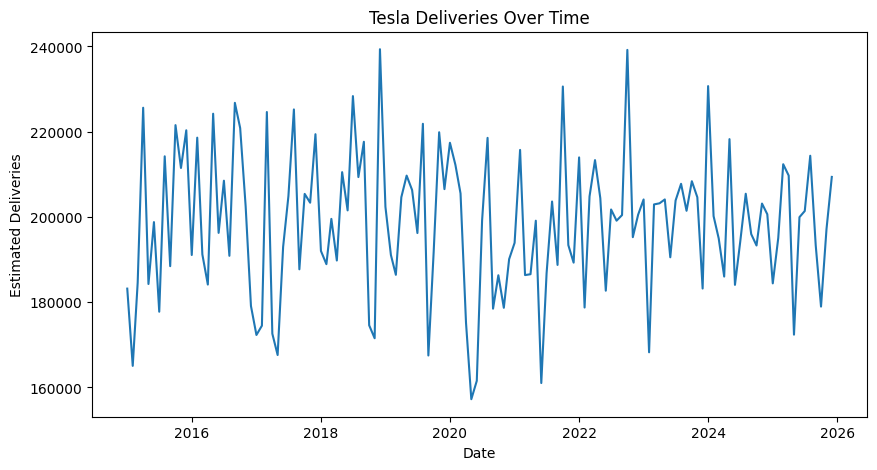

In [28]:
plt.figure(figsize=(10,5))

plt.plot(
    ts_data["Date"],
    ts_data["Estimated_Deliveries"]
)

plt.title("Tesla Deliveries Over Time")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")

plt.show()

In [29]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model_ts = ExponentialSmoothing(
    ts_data["Estimated_Deliveries"],
    trend="add"
)

fit_model = model_ts.fit()

forecast = fit_model.forecast(12)

print(forecast)

132    199248.199014
133    199353.366605
134    199458.534195
135    199563.701785
136    199668.869376
137    199774.036966
138    199879.204557
139    199984.372147
140    200089.539737
141    200194.707328
142    200299.874918
143    200405.042508
dtype: float64


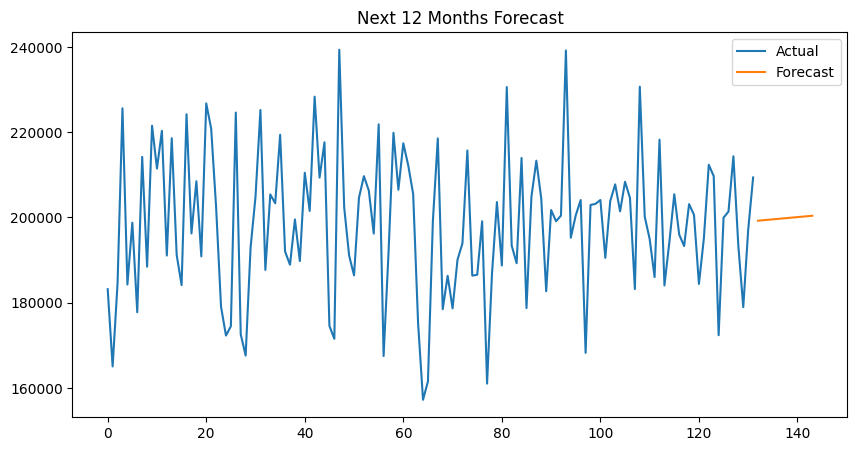

In [30]:
plt.figure(figsize=(10,5))

plt.plot(
    ts_data["Estimated_Deliveries"],
    label="Actual"
)

plt.plot(
    range(len(ts_data),
          len(ts_data)+12),
    forecast,
    label="Forecast"
)

plt.title("Next 12 Months Forecast")
plt.legend()

plt.show()

# Conclusion

In this project, Tesla delivery and production data from 2015–2025 was analyzed using Python.

After data preprocessing and EDA, a Linear Regression model was built to predict estimated deliveries. The model achieved an R² score of 0.99, showing strong prediction performance. A Random Forest model was also tested for comparison.

Finally, a simple time series forecasting model was used to predict future delivery trends. Overall, the project helped understand Tesla's sales patterns and apply machine learning techniques on real-world data.